# Vanilla VAE baseline for atmospheric C 1s spectra

This notebook trains a conventional fully connected Gaussian VAE on the **same self-contained HDF5 dataset and packaged physical-case split** as `prophesy_beta_vae.ipynb`. Each noisy acquisition is the input; its noise-free zero-inelastic-collision peak spectrum is the target. The decoder has a Gaussian observation model with fixed standard deviation in normalized Anscombe units, and the KL term has its standard coefficient of one. There are no peak, area, derivative, or warm-up terms.

The saved outputs document the 12,000-case baseline run. The code below now balances weak, aromatic, and narrow-peak training cases for the continuation dataset; the displayed baseline results do not represent that future retraining. Run cells in order after the continuation is packaged. Required packages: PyTorch, NumPy, h5py, and Matplotlib. Keep the notebook in the `spectraVAE` project folder so it can import `atmospheric_dataset.py`.

In [8]:
from pathlib import Path
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from atmospheric_dataset import h5_manifest, load_atmospheric_c1s

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; device={DEVICE}")

PyTorch 2.6.0; device=cpu


## Load the new dataset

The existing cache is used only if its HDF5 manifest matches the files on disk. Only raw HDF5 data are cached; model weights and outputs are separate. The checkpoint uses a separate baseline output directory.

In [9]:
DATA_ROOT_OVERRIDE = None
DATA_ROOT = Path(DATA_ROOT_OVERRIDE) if DATA_ROOT_OVERRIDE else Path.cwd() / "atmospheric_c1s_h5"
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"HDF5 dataset not found: {DATA_ROOT}")
CACHE_DIR = Path.cwd() / "data_cache"
CACHE_FILE = CACHE_DIR / "atmospheric_c1s_401.npz"
OUTPUT_DIR = Path.cwd() / "outputs" / "atmospheric_vanilla_vae_zero_loss"
CHECKPOINT_FILE = OUTPUT_DIR / "best_vanilla_vae_zero_loss.pt"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
current_manifest = h5_manifest(DATA_ROOT)
if len(current_manifest) < 2:
    raise FileNotFoundError(f"No indexed HDF5 cases found in {DATA_ROOT}")
cache_current = False
if CACHE_FILE.exists():
    with np.load(CACHE_FILE, allow_pickle=False) as cached:
        cache_current = "h5_manifest" in cached.files and np.array_equal(cached["h5_manifest"], current_manifest)
if cache_current:
    with np.load(CACHE_FILE, allow_pickle=False) as cached:
        dataset = {key: cached[key] for key in cached.files if key != "h5_manifest"}
else:
    dataset = load_atmospheric_c1s(DATA_ROOT, target_length=401)
    np.savez_compressed(CACHE_FILE, **dataset, h5_manifest=current_manifest)
print(f"Dataset: {DATA_ROOT}")
print(f"Acquisitions: {len(dataset['noisy']):,}; physical cases: {np.unique(dataset['case_id']).size:,}")
print(f"Energy points: {len(dataset['axis'])}; splits: {dict(zip(*np.unique(dataset['split'], return_counts=True)))}")

Dataset: /home/umar/Downloads/spectraVAE/atmospheric_c1s_h5
Acquisitions: 60,000; physical cases: 12,000
Energy points: 401; splits: {np.str_('test'): np.int64(9040), np.str_('train'): np.int64(41765), np.str_('validation'): np.int64(9195)}


## Case-safe split and normalization

Five noisy acquisitions of each simulated case remain in the same split. The Anscombe scale is determined from training-case total spectra so both the noisy inputs and background-free targets use the same count scale. Training uses SESSA metadata only to sample weak and rare peak shapes more often; these labels do not enter the encoder, decoder, or loss. Validation and test retain their natural frequencies. Saved outputs below are from the earlier uniform-sampling baseline.

In [10]:
case_id = dataset["case_id"]
split = dataset["split"]
train_idx = np.flatnonzero(split == "train")
val_idx = np.flatnonzero(split == "validation")
test_idx = np.flatnonzero(split == "test")
case_sets = [set(np.unique(case_id[index])) for index in (train_idx, val_idx, test_idx)]
assert all(case_sets[i].isdisjoint(case_sets[j]) for i, j in ((0, 1), (0, 2), (1, 2)))
assert sum(map(len, (train_idx, val_idx, test_idx))) == len(case_id)

def anscombe(counts):
    return 2.0 * np.sqrt(np.maximum(counts, 0.0) + 3.0 / 8.0)

TARGET_KEY = "clean"  # SESSA zero-inelastic-collision spectrum, without transport background
TRANSFORM_SCALE = 1.05 * float(anscombe(dataset["expected_total"][train_idx]).max())
def normalize_counts(counts):
    return np.clip(anscombe(counts) / TRANSFORM_SCALE, 0.0, 1.0).astype(np.float32)
def denormalize_counts(values):
    transformed = np.clip(values, 0.0, 1.0) * TRANSFORM_SCALE
    return np.maximum((transformed / 2.0) ** 2 - 3.0 / 8.0, 0.0)

inputs = normalize_counts(dataset["noisy"])
targets = normalize_counts(dataset[TARGET_KEY])
BATCH_SIZE = 512 if DEVICE.type == "cuda" else 256

def make_loader(index, shuffle=False, sampler=None):
    pairs = TensorDataset(torch.from_numpy(inputs[index]), torch.from_numpy(targets[index]))
    return DataLoader(pairs, batch_size=BATCH_SIZE, shuffle=shuffle, sampler=sampler, num_workers=0,
                      pin_memory=DEVICE.type == "cuda")

# Emphasize the low-count, pi-rich, and narrow-peak regimes from the baseline audit.
train_counts = dataset["target_maximum_counts"][train_idx]
train_pi = dataset["peak_fraction"][train_idx, 4]
train_shift = dataset["charge_shift_eV"][train_idx]
train_width = np.nanmedian(np.where(dataset["peak_present"][train_idx].astype(bool),
                                    dataset["peak_width"][train_idx], np.nan), axis=1)
train_weights = np.ones(len(train_idx), dtype=np.float64)
train_weights *= np.where(train_counts < 1000, 1.5, 1.0)
train_weights *= np.where(train_pi >= 0.15, 2.0, np.where(train_pi >= 0.03, 1.25, 1.0))
train_weights *= np.where((train_counts < 1000) & (train_shift > 1.5), 1.25, 1.0)
train_weights *= np.where((train_counts < 1000) & (train_width < 1.1), 1.5, 1.0)
train_sampler = WeightedRandomSampler(torch.as_tensor(train_weights, dtype=torch.double),
                                      num_samples=len(train_idx), replacement=True)
train_loader = make_loader(train_idx, sampler=train_sampler)
val_loader = make_loader(val_idx)
test_loader = make_loader(test_idx)
print(f"Rows: train={len(train_idx):,}, validation={len(val_idx):,}, test={len(test_idx):,}")
print(f"Cases: train={len(case_sets[0]):,}, validation={len(case_sets[1]):,}, test={len(case_sets[2]):,}")
print(f"Anscombe scale: {TRANSFORM_SCALE:.4f}")

Rows: train=41,765, validation=9,195, test=9,040
Cases: train=8,353, validation=1,839, test=1,808
Anscombe scale: 813.2975


## Vanilla Gaussian VAE

A ReLU multilayer perceptron maps 401 intensities to 12 Gaussian latent dimensions. The decoder predicts the Gaussian mean in transformed intensity units. The loss is the usual negative ELBO (up to the Gaussian constant): summed squared error divided by `2 × observation_sigma²`, plus KL divergence to the standard normal, both averaged per spectrum. `OBSERVATION_SIGMA` is a declared likelihood assumption, so record it when comparing runs. The model is selected using deterministic decoding from the encoder mean for stable validation.

In [11]:
LATENT_DIM = 12
OBSERVATION_SIGMA = 0.03
EPOCHS = 150
LEARNING_RATE = 3e-4
PATIENCE = 20
MIN_DELTA = 0.01

class VanillaVAE(nn.Module):
    def __init__(self, input_dim=401, latent_dim=12):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, input_dim),
        )

    def encode(self, x):
        features = self.encoder(x)
        return self.mu(features), self.logvar(features)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z), mu, logvar

def loss_parts(reconstruction, target, mu, logvar):
    squared = (reconstruction - target).square().sum(dim=1)
    gaussian_nll = (squared / (2.0 * OBSERVATION_SIGMA ** 2)).mean()
    kl = (-0.5 * (1.0 + logvar - mu.square() - logvar.exp()).sum(dim=1)).mean()
    return gaussian_nll + kl, gaussian_nll, kl

model = VanillaVAE(input_dim=len(dataset["axis"]), latent_dim=LATENT_DIM).to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

VanillaVAE(
  (encoder): Sequential(
    (0): Linear(in_features=401, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (mu): Linear(in_features=64, out_features=12, bias=True)
  (logvar): Linear(in_features=64, out_features=12, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=401, bias=True)
  )
)
Trainable parameters: 290,857


## Train and retain the best validation checkpoint

Training samples the latent posterior. Validation decodes its mean to avoid selection noise; the displayed validation score is therefore a deterministic selection score, rather than a Monte Carlo estimate of the ELBO.

In [12]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    totals = np.zeros(3, dtype=np.float64)
    count = 0
    for x, target in loader:
        x, target = x.to(DEVICE), target.to(DEVICE)
        mu, logvar = model.encode(x)
        values = loss_parts(model.decode(mu), target, mu, logvar)
        totals += np.array([value.item() for value in values]) * len(x)
        count += len(x)
    return totals / count

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_total": [], "train_reconstruction": [], "train_kl": [],
           "val_total": [], "val_reconstruction": [], "val_kl": []}
best_score = float("inf")
best_state = None
stale_epochs = 0
start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    totals = np.zeros(3, dtype=np.float64)
    count = 0
    for x, target in train_loader:
        x, target = x.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        reconstruction, mu, logvar = model(x)
        values = loss_parts(reconstruction, target, mu, logvar)
        values[0].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        totals += np.array([value.item() for value in values]) * len(x)
        count += len(x)
    train_values = totals / count
    val_values = evaluate(val_loader)
    for group, values in (("train", train_values), ("val", val_values)):
        for name, value in zip(("total", "reconstruction", "kl"), values):
            history[f"{group}_{name}"].append(value)
    if np.isfinite(val_values[0]) and val_values[0] < best_score - MIN_DELTA:
        best_score = float(val_values[0])
        best_state = copy.deepcopy(model.state_dict())
        stale_epochs = 0
        torch.save({"model_state_dict": best_state, "latent_dim": LATENT_DIM,
                    "observation_sigma": OBSERVATION_SIGMA, "transform_scale": TRANSFORM_SCALE,
                    "target_key": TARGET_KEY,
                    "h5_manifest": current_manifest.tolist(), "seed": SEED}, CHECKPOINT_FILE)
    else:
        stale_epochs += 1
    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:03d}: train={train_values[0]:.3f} "
              f"(nll={train_values[1]:.3f}, kl={train_values[2]:.3f}); "
              f"val={val_values[0]:.3f}")
    if stale_epochs >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break
if best_state is None:
    raise RuntimeError("Training did not produce a finite validation checkpoint")
model.load_state_dict(best_state)
print(f"Best validation score: {best_score:.3f}; time: {(time.time()-start_time)/60:.1f} min")
print(f"Checkpoint: {CHECKPOINT_FILE}")

epoch 001: train=1460.711 (nll=1445.532, kl=15.179); val=597.566
epoch 010: train=216.332 (nll=187.003, kl=29.329); val=206.791
epoch 020: train=131.118 (nll=103.380, kl=27.738); val=123.182
epoch 030: train=91.884 (nll=64.790, kl=27.095); val=86.027
epoch 040: train=73.499 (nll=47.764, kl=25.736); val=70.384
epoch 050: train=66.306 (nll=42.330, kl=23.976); val=62.434
epoch 060: train=62.112 (nll=39.524, kl=22.588); val=58.466
epoch 070: train=57.696 (nll=35.876, kl=21.820); val=55.658
epoch 080: train=51.234 (nll=29.617, kl=21.617); val=48.198
epoch 090: train=47.530 (nll=26.410, kl=21.120); val=45.557
epoch 100: train=45.286 (nll=24.636, kl=20.650); val=43.080
epoch 110: train=43.808 (nll=23.605, kl=20.203); val=41.161
epoch 120: train=42.136 (nll=22.366, kl=19.769); val=40.972
epoch 130: train=41.228 (nll=21.763, kl=19.465); val=40.924
epoch 140: train=40.349 (nll=21.048, kl=19.301); val=39.906
epoch 150: train=39.559 (nll=20.417, kl=19.142); val=40.674
Best validation score: 38.520

## Baseline diagnostics on held-out physical cases

Evaluate the predicted zero-loss signal directly against the held-out zero-loss target. These scores measure denoising and background removal together. The saved β-VAE scores used the background-containing total spectrum and are not directly comparable.

The plots show the three best and three worst held-out physical cases, ranked by median normalized RMSE across each case's noisy acquisitions. One acquisition nearest that median represents each case.


Deterministic test selection score: 39.795
NRMSE                         p50=0.033  p90=0.079  p95=0.093
Area error                    p50=3.360%  p90=10.050%  p95=13.113%
Peak-height error             p50=6.961%  p90=25.154%  p95=32.777%
Dominant-peak position error  p50=0.100 eV  p90=0.450 eV  p95=1.050 eV


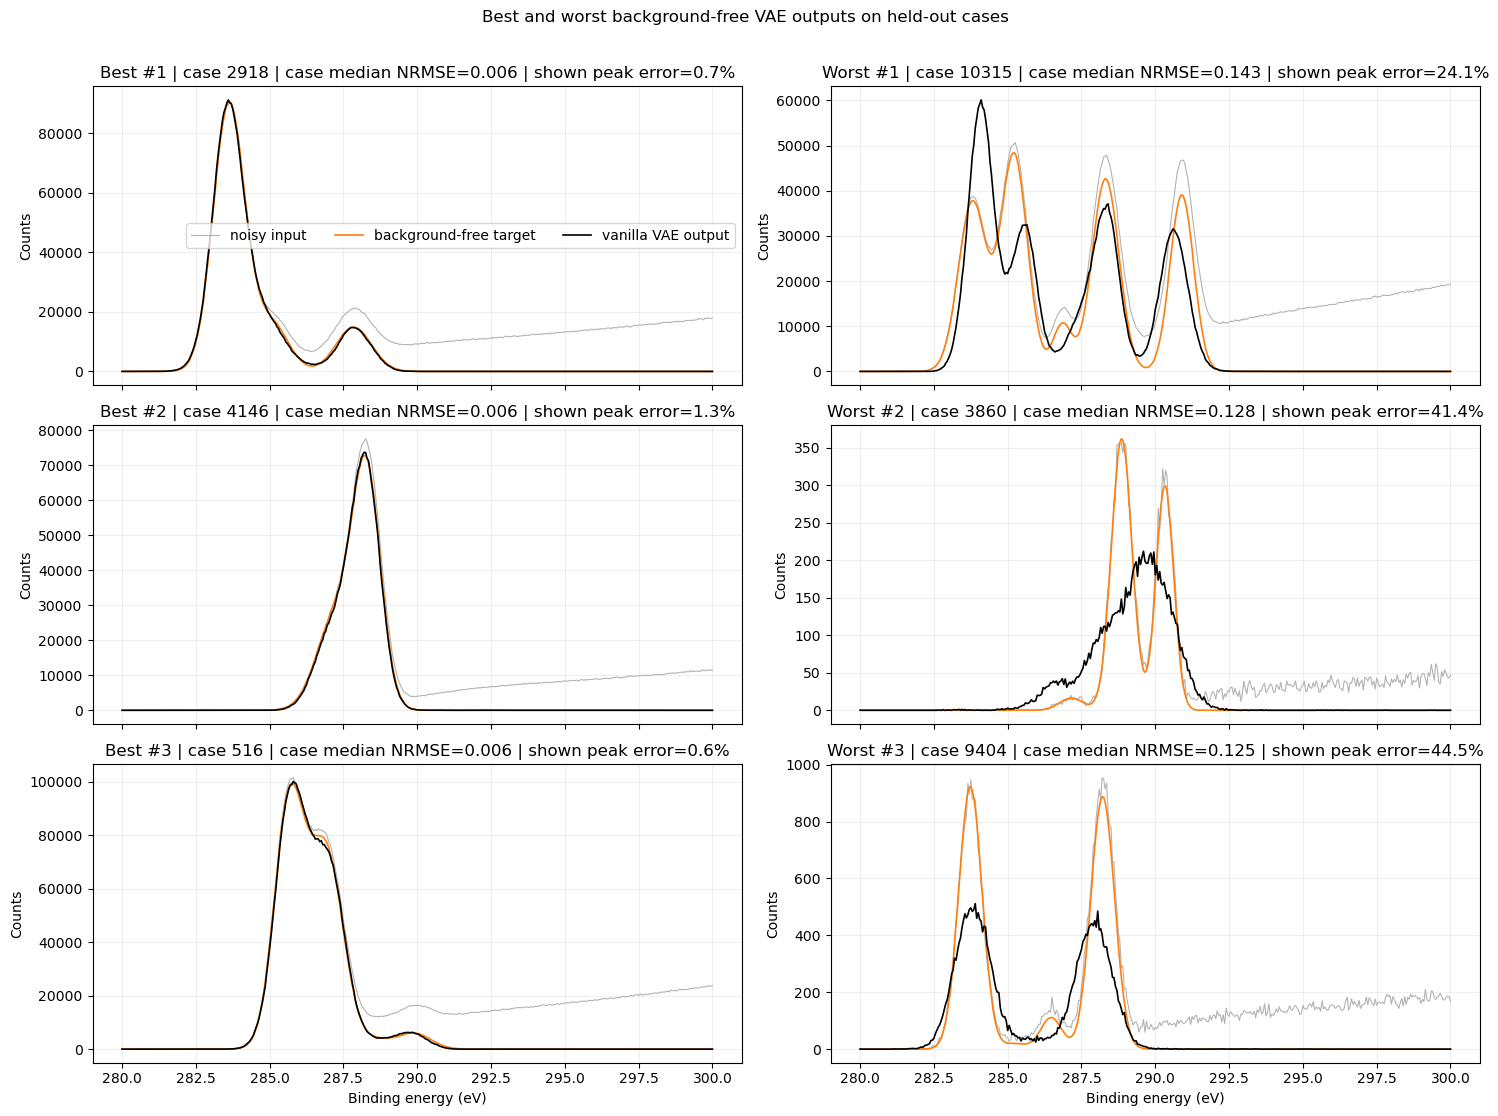

In [16]:
@torch.no_grad()
def reconstruct_mean(values, batch_size=1024):
    model.eval()
    chunks = []
    for start in range(0, len(values), batch_size):
        x = torch.from_numpy(values[start:start+batch_size]).to(DEVICE)
        mu, _ = model.encode(x)
        chunks.append(model.decode(mu).cpu().numpy())
    return np.concatenate(chunks)

prediction = denormalize_counts(reconstruct_mean(inputs[test_idx]))
target = dataset[TARGET_KEY][test_idx]
axis = dataset["axis"]
rmse = np.sqrt(np.mean((prediction-target)**2, axis=1))
nrmse = rmse / np.maximum(np.ptp(target, axis=1), 1.0)
area_error = np.abs(prediction.sum(axis=1)-target.sum(axis=1)) / np.maximum(target.sum(axis=1), 1.0)
peak_error = np.abs(prediction.max(axis=1)-target.max(axis=1)) / np.maximum(target.max(axis=1), 1.0)
position_error = np.abs(axis[np.argmax(prediction, axis=1)]-axis[np.argmax(target, axis=1)])
print(f"Deterministic test selection score: {evaluate(test_loader)[0]:.3f}")
for name, values, scale, unit in (
    ("NRMSE", nrmse, 1, ""),
    ("Area error", area_error, 100, "%"),
    ("Peak-height error", peak_error, 100, "%"),
    ("Dominant-peak position error", position_error, 1, " eV"),
):
    q = np.quantile(values, [0.5, 0.9, 0.95]) * scale
    print(f"{name:<29} p50={q[0]:.3f}{unit}  p90={q[1]:.3f}{unit}  p95={q[2]:.3f}{unit}")

test_case_ids = case_id[test_idx]
case_scores = []
case_representatives = []
for physical_case in np.unique(test_case_ids):
    positions = np.flatnonzero(test_case_ids == physical_case)
    median_error = np.median(nrmse[positions])
    case_scores.append(median_error)
    case_representatives.append(positions[np.argmin(np.abs(nrmse[positions] - median_error))])
case_scores = np.asarray(case_scores)
case_representatives = np.asarray(case_representatives)
case_order = np.argsort(case_scores)
best_cases = case_order[:3]
worst_cases = case_order[-3:][::-1]

fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
for rank, (best_case, worst_case) in enumerate(zip(best_cases, worst_cases), start=1):
    for column, case_index in enumerate((best_case, worst_case)):
        pos = case_representatives[case_index]
        row = test_idx[pos]
        ax = axes[rank - 1, column]
        ax.plot(axis, dataset["noisy"][row], color="0.7", lw=0.8, label="noisy input")
        ax.plot(axis, target[pos], color="tab:orange", lw=1.2, label="background-free target")
        ax.plot(axis, prediction[pos], color="black", lw=1.2, label="vanilla VAE output")
        label = "Best" if column == 0 else "Worst"
        ax.set_title(f"{label} #{rank} | case {case_id[row]} | case median NRMSE={case_scores[case_index]:.3f}"
                     f" | shown peak error={peak_error[pos]:.1%}")
        ax.set_ylabel("Counts")
        ax.grid(alpha=0.2)
axes[0, 0].legend(ncol=3)
for ax in axes[-1]:
    ax.set_xlabel("Binding energy (eV)")
fig.suptitle("Best and worst background-free VAE outputs on held-out cases", y=1.01)
plt.tight_layout()
plt.show()

## Decode interpolations between training cases

To inspect generation on the learned data manifold, encode one training acquisition per physical case and interpolate between nearby latent means. This section makes no independent latent draw. Decoded interpolations represent background-free peak spectra. Inspect their sharp components against the test reconstructions above.

Std of encoder means: [0.228 0.841 0.928 0.03  1.059 1.097 0.765 0.953 0.942 0.015 0.02  0.896]
Active dimensions: [0, 1, 2, 4, 5, 6, 7, 8, 11]


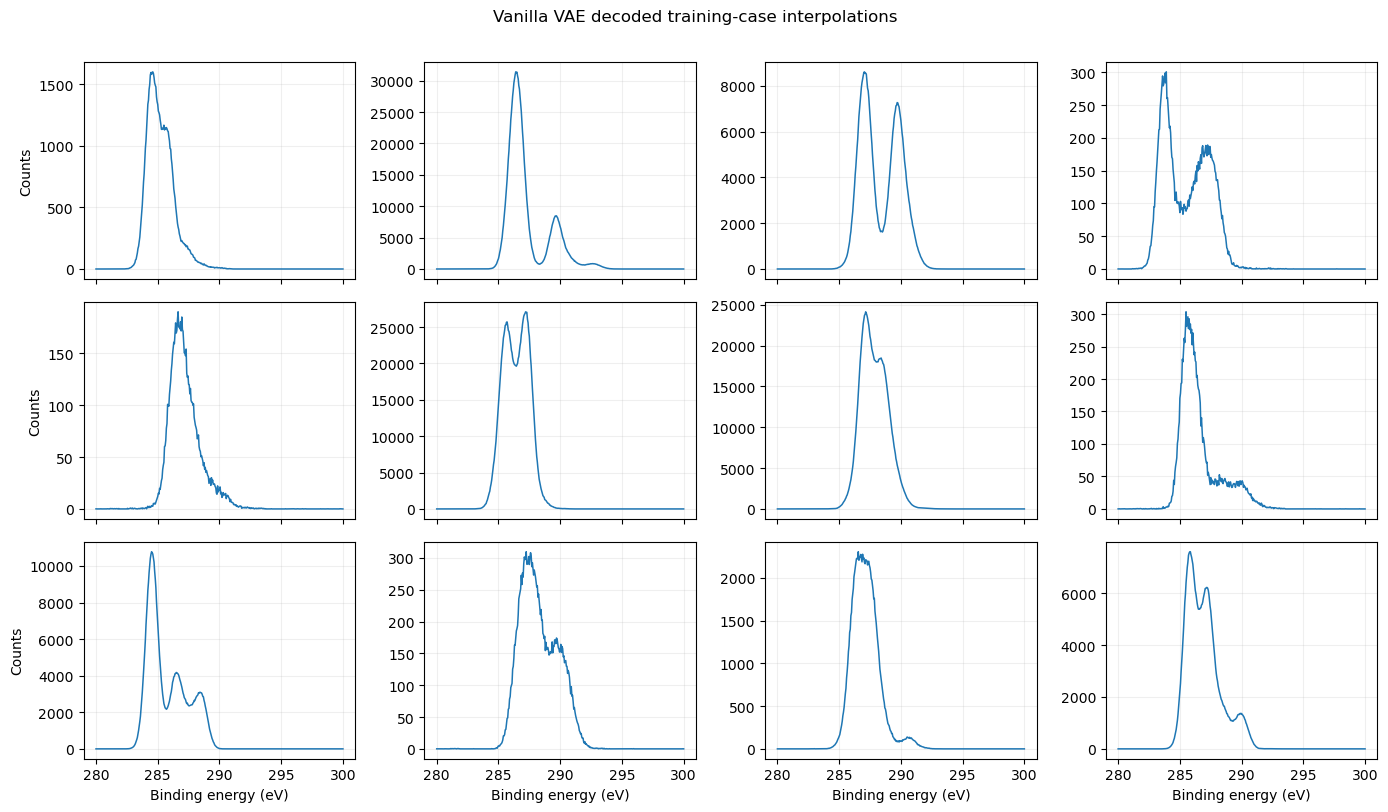

In [14]:
@torch.no_grad()
def encode_means(values, batch_size=1024):
    model.eval()
    chunks = []
    for start in range(0, len(values), batch_size):
        x = torch.from_numpy(values[start:start+batch_size]).to(DEVICE)
        mu, _ = model.encode(x)
        chunks.append(mu.cpu().numpy())
    return np.concatenate(chunks)

_, representative_rows = np.unique(case_id[train_idx], return_index=True)
train_representatives = train_idx[representative_rows]
latent_means = encode_means(inputs[train_representatives])
latent_std = latent_means.std(axis=0)
active = np.flatnonzero(latent_std > 0.05)
print("Std of encoder means:", np.round(latent_std, 3))
print("Active dimensions:", active.tolist())
if not len(active):
    raise RuntimeError("No active latent means; interpolation would be uninformative")
scaled = latent_means[:, active] / latent_std[active]
rng = np.random.default_rng(SEED + 2)
anchors = rng.choice(len(latent_means), size=12, replace=False)
new_latents = []
for anchor in anchors:
    candidates = rng.choice(len(latent_means), size=min(512, len(latent_means)), replace=False)
    candidates = candidates[candidates != anchor]
    distances = np.sum((scaled[candidates]-scaled[anchor])**2, axis=1)
    neighbor = rng.choice(candidates[np.argsort(distances)[:20]])
    weight = rng.uniform(0.25, 0.75)
    new_latents.append((1-weight)*latent_means[anchor] + weight*latent_means[neighbor])
with torch.no_grad():
    decoded = model.decode(torch.tensor(np.array(new_latents), dtype=torch.float32, device=DEVICE)).cpu().numpy()
generated = denormalize_counts(decoded)
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True)
for ax, spectrum in zip(axes.flat, generated):
    ax.plot(axis, spectrum, lw=1.1)
    ax.grid(alpha=0.2)
for ax in axes[-1]:
    ax.set_xlabel("Binding energy (eV)")
for ax in axes[:, 0]:
    ax.set_ylabel("Counts")
fig.suptitle("Vanilla VAE decoded training-case interpolations", y=1.01)
plt.tight_layout()
plt.show()

Loaded checkpoint: /home/umar/Downloads/spectraVAE/outputs/atmospheric_vanilla_vae_zero_loss/best_vanilla_vae_zero_loss.pt
Latent dimensions: 12
Observation sigma: 0.03

TEST SET RESULTS
Number of test spectra: 9,040
Number of physical cases: 1,808

Mean RMSE:                  558.9936
Median NRMSE:               0.0327
Median area error:          3.36%
Median peak-height error:   6.96%
Median peak-position error: 0.1000 eV

90th percentile:
NRMSE:                      0.0791
Area error:                 10.05%
Peak-height error:          25.15%
Peak-position error:        0.4500 eV


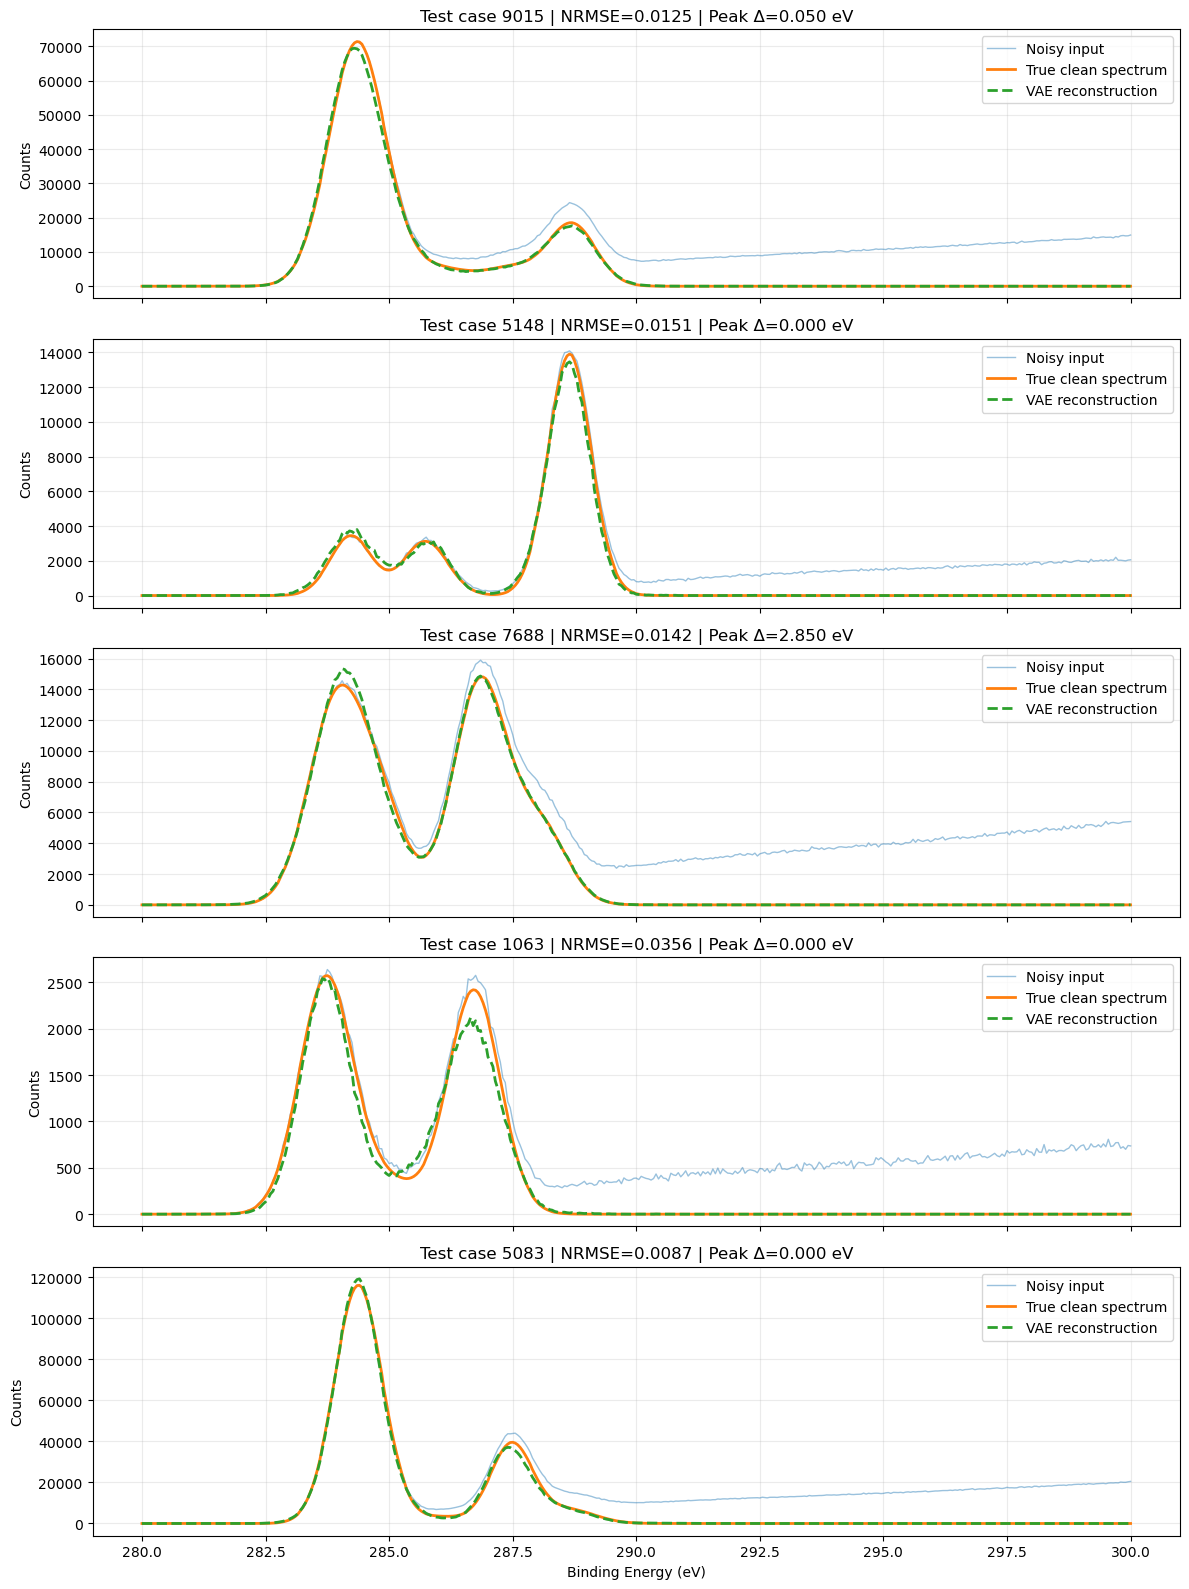

In [19]:
# ============================================================
# TEST THE TRAINED VANILLA VAE ON UNSEEN TEST DATA
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load BEST saved model
# ------------------------------------------------------------
checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)

test_model = VanillaVAE(
    input_dim=len(dataset["axis"]),
    latent_dim=checkpoint["latent_dim"]
).to(DEVICE)

test_model.load_state_dict(checkpoint["model_state_dict"])
test_model.eval()

print(f"Loaded checkpoint: {CHECKPOINT_FILE}")
print(f"Latent dimensions: {checkpoint['latent_dim']}")
print(f"Observation sigma: {checkpoint['observation_sigma']}")
print()

# ------------------------------------------------------------
# 2. Reconstruct ALL unseen test spectra
#    Use latent mean mu instead of random sampling so the
#    evaluation is deterministic.
# ------------------------------------------------------------
@torch.no_grad()
def reconstruct_test(values, batch_size=1024):
    outputs = []

    for start in range(0, len(values), batch_size):
        x = torch.from_numpy(
            values[start:start + batch_size]
        ).float().to(DEVICE)

        mu, logvar = test_model.encode(x)
        reconstruction = test_model.decode(mu)

        outputs.append(reconstruction.cpu().numpy())

    return np.concatenate(outputs, axis=0)


# Normalized VAE predictions
pred_norm = reconstruct_test(inputs[test_idx])

# Convert back to original count scale
pred = denormalize_counts(pred_norm)

# Ground truth and noisy spectra in original count scale
clean = dataset[TARGET_KEY][test_idx]
noisy = dataset["noisy"][test_idx]

axis = dataset["axis"]


# ------------------------------------------------------------
# 3. Calculate test metrics
# ------------------------------------------------------------

# RMSE
rmse = np.sqrt(
    np.mean((pred - clean) ** 2, axis=1)
)

# Normalized RMSE
nrmse = rmse / np.maximum(
    np.ptp(clean, axis=1),
    1.0
)

# Area error
area_error = (
    np.abs(pred.sum(axis=1) - clean.sum(axis=1))
    / np.maximum(clean.sum(axis=1), 1.0)
)

# Peak height error
peak_height_error = (
    np.abs(pred.max(axis=1) - clean.max(axis=1))
    / np.maximum(clean.max(axis=1), 1.0)
)

# Dominant peak position error
pred_peak_position = axis[np.argmax(pred, axis=1)]
true_peak_position = axis[np.argmax(clean, axis=1)]

peak_position_error = np.abs(
    pred_peak_position - true_peak_position
)


# ------------------------------------------------------------
# 4. Print summary
# ------------------------------------------------------------

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)

print(f"Number of test spectra: {len(test_idx):,}")
print(f"Number of physical cases: "
      f"{len(np.unique(dataset['case_id'][test_idx])):,}")

print()

print(f"Mean RMSE:                  {rmse.mean():.4f}")
print(f"Median NRMSE:               {np.median(nrmse):.4f}")
print(f"Median area error:          {np.median(area_error)*100:.2f}%")
print(f"Median peak-height error:   {np.median(peak_height_error)*100:.2f}%")
print(f"Median peak-position error: {np.median(peak_position_error):.4f} eV")

print()
print("90th percentile:")
print(f"NRMSE:                      {np.quantile(nrmse, 0.90):.4f}")
print(f"Area error:                 {np.quantile(area_error, 0.90)*100:.2f}%")
print(f"Peak-height error:          {np.quantile(peak_height_error, 0.90)*100:.2f}%")
print(f"Peak-position error:        {np.quantile(peak_position_error, 0.90):.4f} eV")


# ------------------------------------------------------------
# 5. Plot random UNSEEN test examples
# ------------------------------------------------------------

rng = np.random.default_rng(42)
examples = rng.choice(len(test_idx), size=5, replace=False)

fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 16),
    sharex=True
)

for ax, i in zip(axes, examples):

    original_row = test_idx[i]
    case = dataset["case_id"][original_row]

    ax.plot(
        axis,
        noisy[i],
        alpha=0.45,
        linewidth=1,
        label="Noisy input"
    )

    ax.plot(
        axis,
        clean[i],
        linewidth=2,
        label="True clean spectrum"
    )

    ax.plot(
        axis,
        pred[i],
        "--",
        linewidth=2,
        label="VAE reconstruction"
    )

    ax.set_title(
        f"Test case {case} | "
        f"NRMSE={nrmse[i]:.4f} | "
        f"Peak Δ={peak_position_error[i]:.3f} eV"
    )

    ax.set_ylabel("Counts")
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Binding Energy (eV)")

plt.tight_layout()
plt.show()


TEST SET NRMSE RANKING
Total test spectra: 9,040
Best NRMSE:         0.00358
Median NRMSE:       0.03266
Worst NRMSE:        0.20828

5 BEST RECONSTRUCTIONS
#   Case ID        NRMSE       RMSE          Area Err      Height Err    Peak Pos Err   
----------------------------------------------------------------------------------------------------
1   553            0.0036      309.47        1.10         %0.19         %0.0500         
2   4640           0.0036      137.25        1.45         %0.35         %0.0500         
3   1981           0.0038      183.36        0.51         %0.08         %0.0000         
4   553            0.0038      369.18        0.97         %0.14         %0.0500         
5   4512           0.0039      89.05         1.64         %0.68         %0.0500         

5 RECONSTRUCTIONS AROUND THE MEDIAN
#   Case ID        NRMSE       RMSE          Area Err      Height Err    Peak Pos Err   
---------------------------------------------------------------------------------

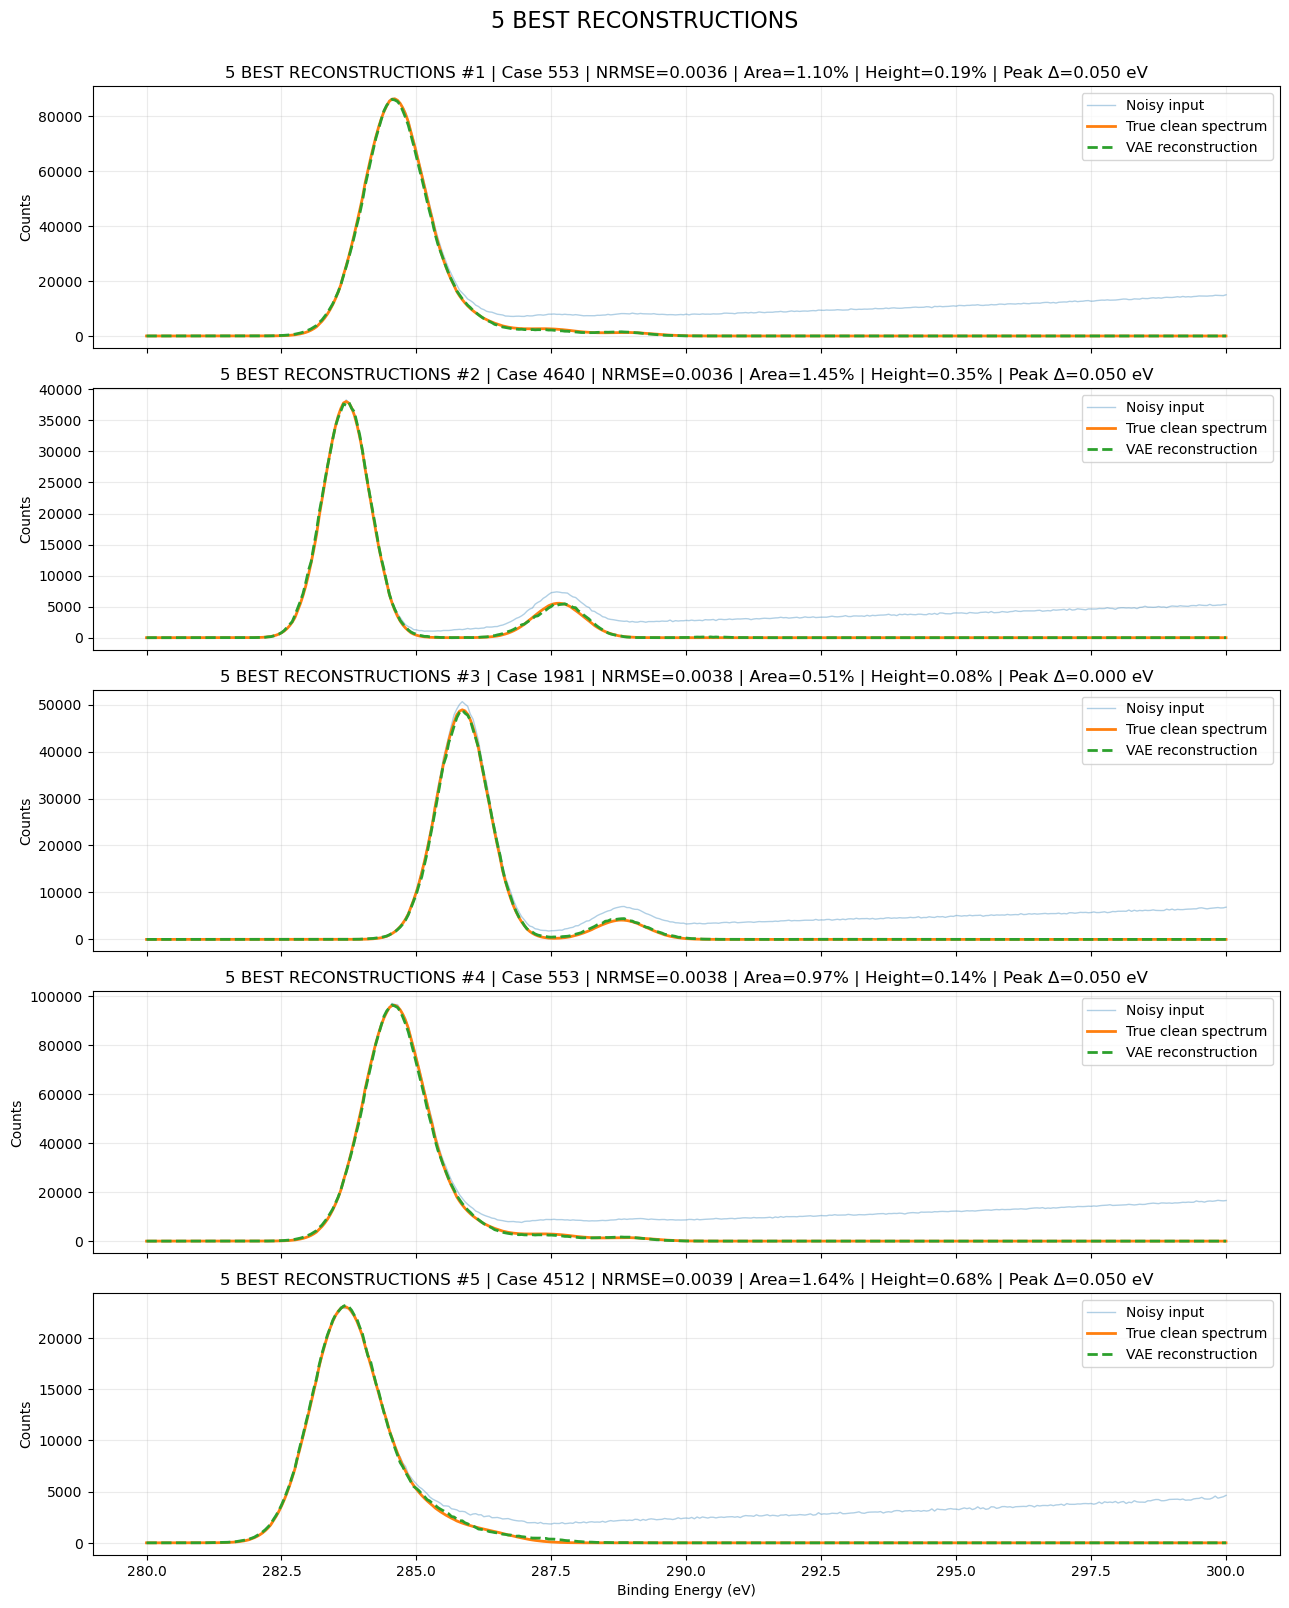

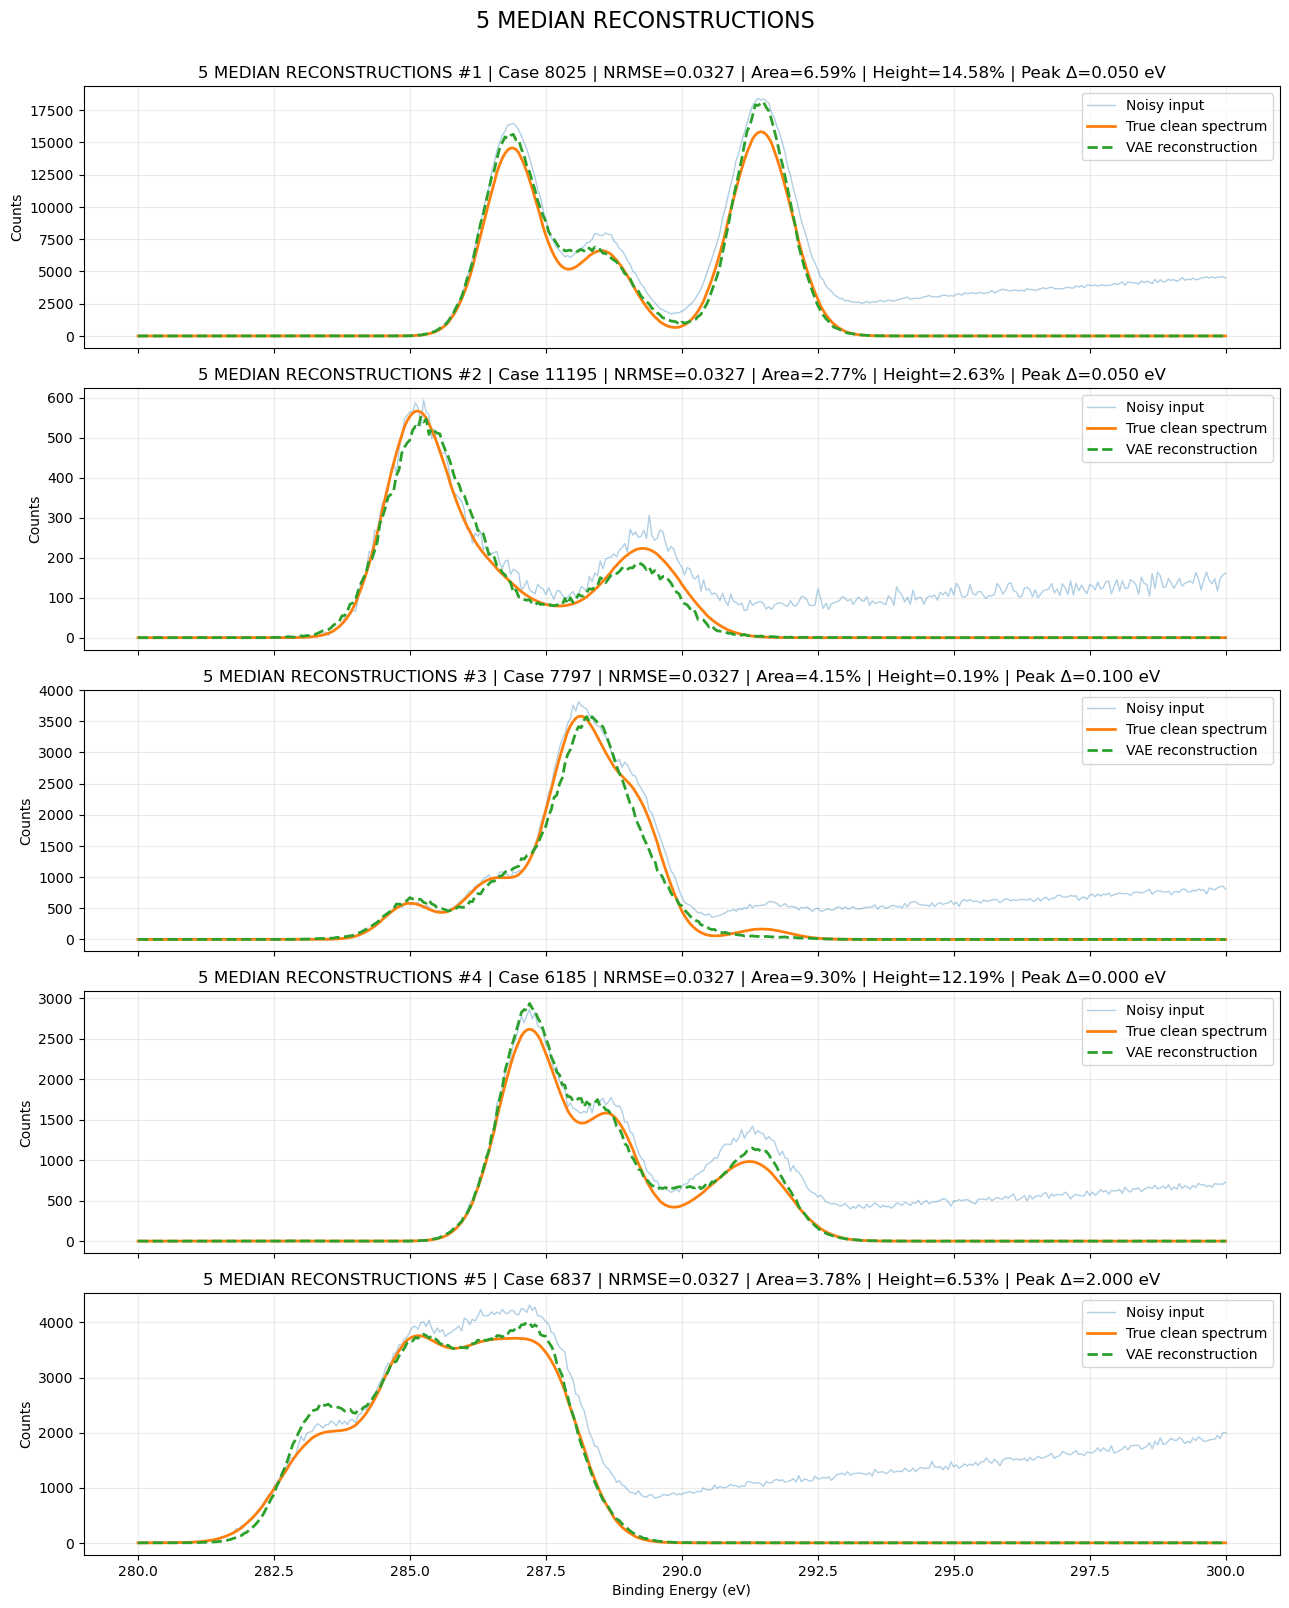

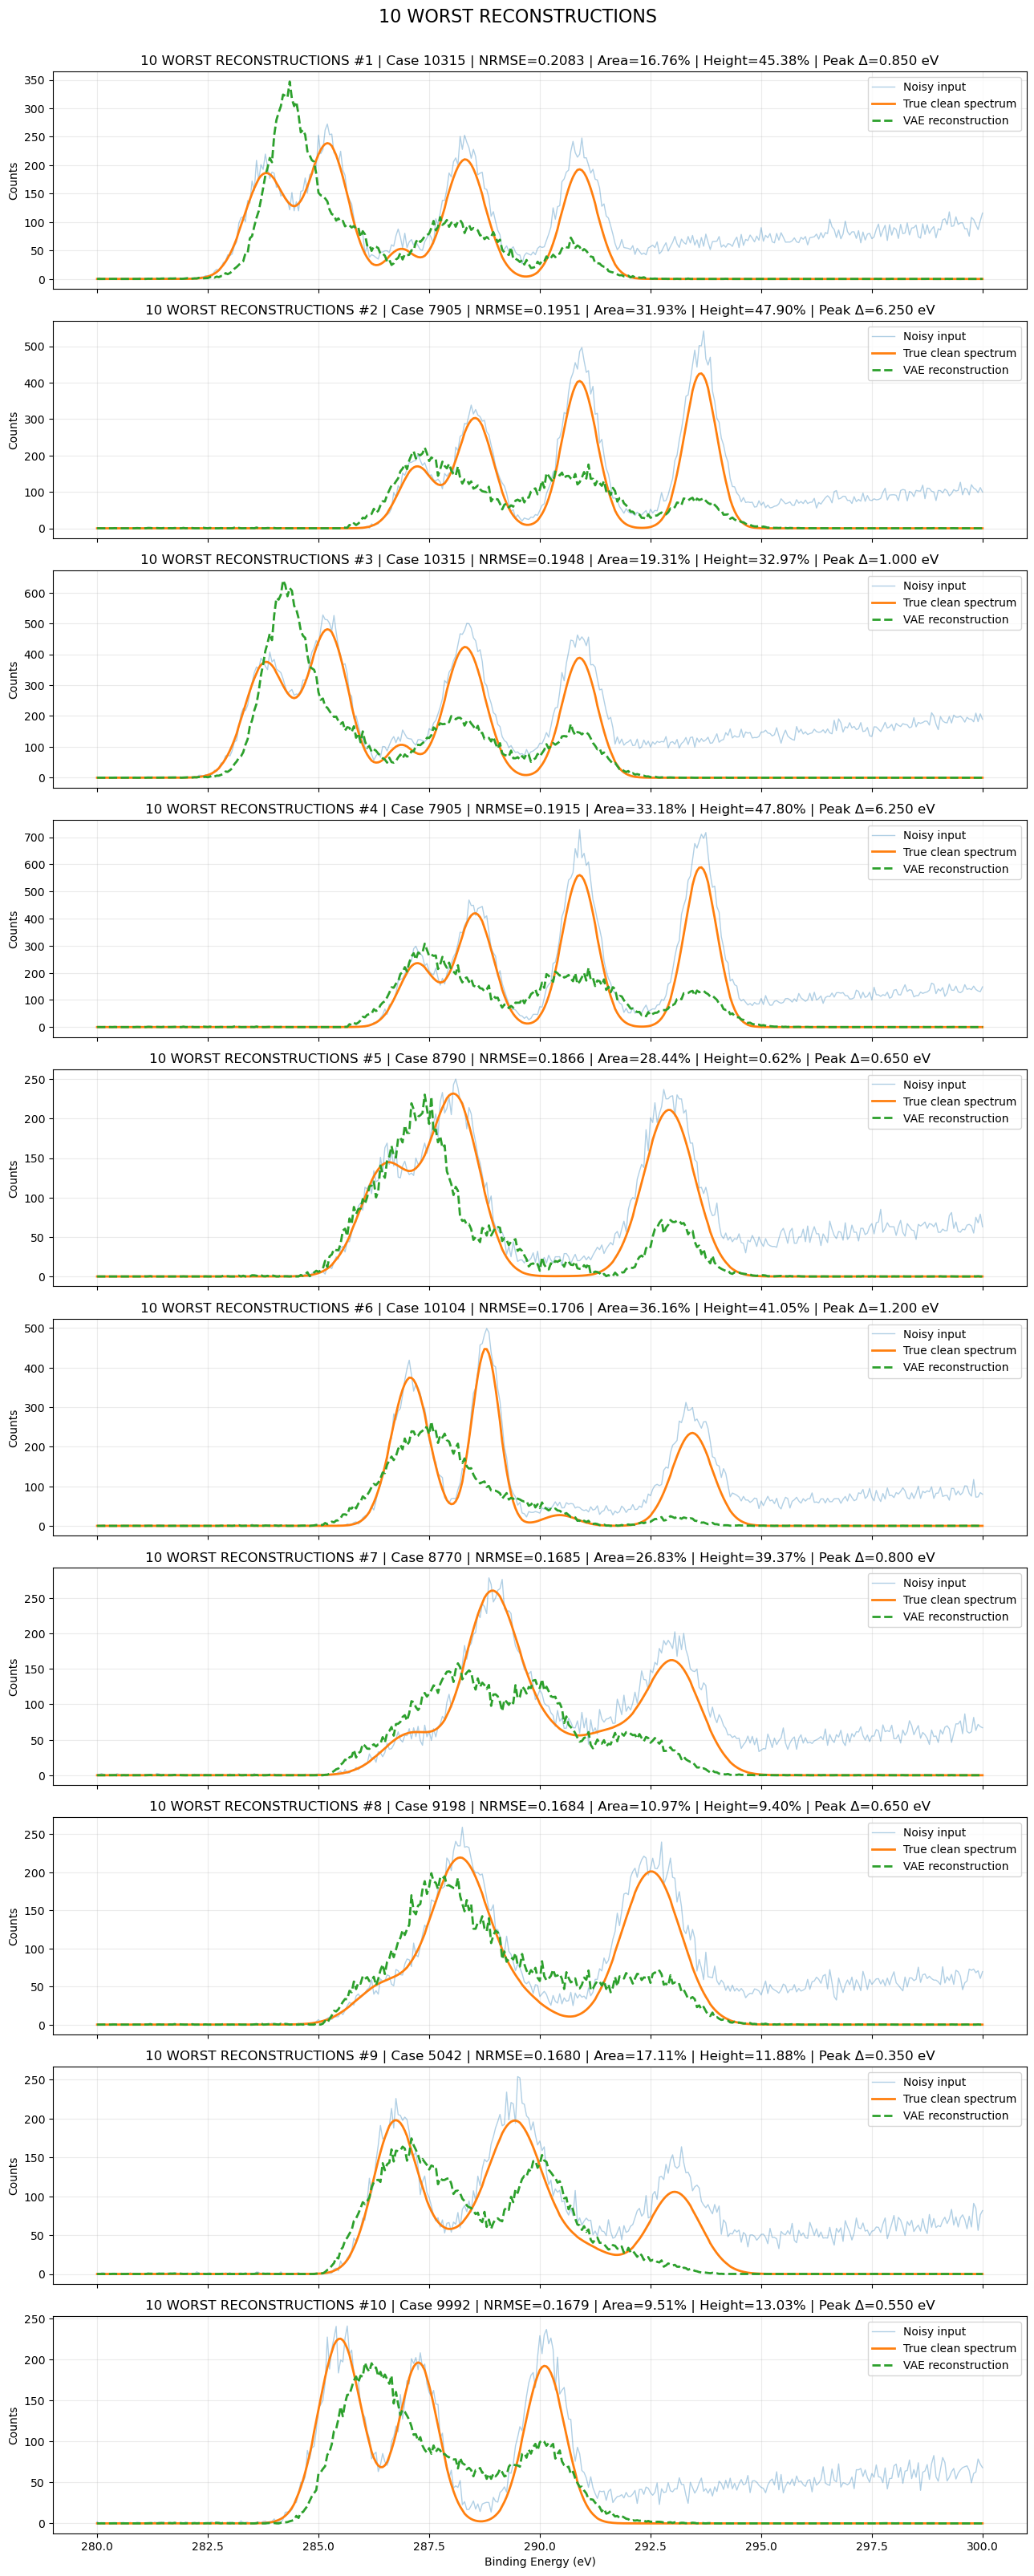

In [20]:
# ============================================================
# RANK TEST RECONSTRUCTIONS BY NRMSE
# Plot: 5 BEST + 5 MEDIAN + 10 WORST
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Rank all test spectra by NRMSE
# ------------------------------------------------------------

ranked = np.argsort(nrmse)   # lowest NRMSE -> highest NRMSE

# 5 best
best_idx = ranked[:5]

# 5 around the median
mid = len(ranked) // 2
median_idx = ranked[mid - 2:mid + 3]

# 10 worst
worst_idx = ranked[-10:][::-1]   # worst first


# ------------------------------------------------------------
# 2. Helper to print metrics
# ------------------------------------------------------------

def print_metrics(group_name, indices):
    print("\n" + "=" * 100)
    print(group_name)
    print("=" * 100)

    print(
        f"{'#':<4}"
        f"{'Case ID':<15}"
        f"{'NRMSE':<12}"
        f"{'RMSE':<14}"
        f"{'Area Err':<14}"
        f"{'Height Err':<14}"
        f"{'Peak Pos Err':<15}"
    )

    print("-" * 100)

    for rank, i in enumerate(indices, 1):

        original_row = test_idx[i]
        case_id = dataset["case_id"][original_row]

        print(
            f"{rank:<4}"
            f"{str(case_id):<15}"
            f"{nrmse[i]:<12.4f}"
            f"{rmse[i]:<14.2f}"
            f"{area_error[i]*100:<13.2f}%"
            f"{peak_height_error[i]*100:<13.2f}%"
            f"{peak_position_error[i]:<15.4f}"
        )


# ------------------------------------------------------------
# 3. Helper to plot spectra
# ------------------------------------------------------------

def plot_group(group_name, indices):

    n = len(indices)

    fig, axes = plt.subplots(
        n,
        1,
        figsize=(13, 3.2 * n),
        sharex=True
    )

    # If only one plot exists, make axes iterable
    if n == 1:
        axes = [axes]

    for rank, (ax, i) in enumerate(zip(axes, indices), 1):

        original_row = test_idx[i]
        case_id = dataset["case_id"][original_row]

        # Noisy input
        ax.plot(
            axis,
            noisy[i],
            alpha=0.35,
            linewidth=1,
            label="Noisy input"
        )

        # Ground truth
        ax.plot(
            axis,
            clean[i],
            linewidth=2,
            label="True clean spectrum"
        )

        # VAE reconstruction
        ax.plot(
            axis,
            pred[i],
            "--",
            linewidth=2,
            label="VAE reconstruction"
        )

        ax.set_title(
            f"{group_name} #{rank} | "
            f"Case {case_id} | "
            f"NRMSE={nrmse[i]:.4f} | "
            f"Area={area_error[i]*100:.2f}% | "
            f"Height={peak_height_error[i]*100:.2f}% | "
            f"Peak Δ={peak_position_error[i]:.3f} eV"
        )

        ax.set_ylabel("Counts")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")

    axes[-1].set_xlabel("Binding Energy (eV)")

    fig.suptitle(
        group_name,
        fontsize=16,
        y=1.002
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Print ranking information
# ------------------------------------------------------------

print("\nTEST SET NRMSE RANKING")
print("=" * 100)

print(f"Total test spectra: {len(nrmse):,}")
print(f"Best NRMSE:         {nrmse[ranked[0]]:.5f}")
print(f"Median NRMSE:       {np.median(nrmse):.5f}")
print(f"Worst NRMSE:        {nrmse[ranked[-1]]:.5f}")


print_metrics(
    "5 BEST RECONSTRUCTIONS",
    best_idx
)

print_metrics(
    "5 RECONSTRUCTIONS AROUND THE MEDIAN",
    median_idx
)

print_metrics(
    "10 WORST RECONSTRUCTIONS",
    worst_idx
)


# ------------------------------------------------------------
# 5. Plot groups
# ------------------------------------------------------------

plot_group(
    "5 BEST RECONSTRUCTIONS",
    best_idx
)

plot_group(
    "5 MEDIAN RECONSTRUCTIONS",
    median_idx
)

plot_group(
    "10 WORST RECONSTRUCTIONS",
    worst_idx
)